# Análisis de COMPAS

Este notebook contiene la conversión a Python del análisis de ProPublica sobre las puntuaciones de riesgo de reincidencia de COMPAS. La metodología original puede consultarse en [este enlace](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/).

## Requisitos y archivos de datos

Coloca los siguientes archivos CSV en el mismo directorio que este notebook:

- `compas-scores-two-years.csv`
- `compas-scores-two-years-violent.csv`
- `cox-parsed.csv`
- `cox-violent-parsed.csv`

Instala las dependencias antes de ejecutar el notebook:

```bash
pip install pandas numpy matplotlib statsmodels lifelines
```

## Carga de datos

Se utilizan variables sobre la gravedad del cargo, antecedentes, características demográficas, edad, sexo, puntuaciones COMPAS y reincidencia durante los dos años posteriores.

In [70]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
from lifelines import CoxTimeVaryingFitter, KaplanMeierFitter

RUTA_DATOS = Path("data//raw")

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)


def mostrar_frecuencias(serie):
    """Muestra las frecuencias absolutas de una serie, incluyendo valores faltantes."""
    return serie.value_counts(dropna=False)


def porcentaje(parte, total):
    """Calcula un porcentaje y devuelve NaN si el denominador es cero."""
    return np.nan if total == 0 else 100 * parte / total


def division_segura(numerador, denominador):
    """Calcula una división y devuelve NaN si el denominador es cero."""
    return np.nan if denominador == 0 else numerador / denominador


def preparar_datos_cox(datos):
    """
    Genera variables indicadoras para los modelos de Cox.

    Las categorías de referencia son: riesgo bajo y personas caucásicas.
    """
    resultado = datos.copy()

    resultado["score_text"] = pd.Categorical(
        resultado["score_text"],
        categories=["Low", "Medium", "High"],
        ordered=True,
    )
    indicadores_puntaje = pd.get_dummies(
        resultado["score_text"],
        prefix="puntaje",
        drop_first=True,
        dtype=int,
    )
    resultado = pd.concat([resultado, indicadores_puntaje], axis=1)

    resultado["race"] = pd.Categorical(
        resultado["race"],
        categories=[
            "Caucasian",
            "African-American",
            "Asian",
            "Hispanic",
            "Native American",
            "Other",
        ],
    )
    indicadores_raza = pd.get_dummies(
        resultado["race"],
        prefix="raza",
        drop_first=True,
        dtype=int,
    )
    resultado = pd.concat([resultado, indicadores_raza], axis=1)

    columnas_puntaje = [columna for columna in resultado.columns if columna.startswith("puntaje_")]
    columnas_raza = [columna for columna in resultado.columns if columna.startswith("raza_")]

    for columna_raza in columnas_raza:
        for columna_puntaje in columnas_puntaje:
            nombre = f"{columna_raza}_x_{columna_puntaje}"
            resultado[nombre] = resultado[columna_raza] * resultado[columna_puntaje]

    return resultado


def ajustar_modelo_cox(datos, covariables):
    """
    Ajusta un modelo de Cox para datos con intervalos de tiempo.

    Parámetros:
        datos: DataFrame con id, inicio, fin, evento y las covariables.
        covariables: Lista de columnas predictoras.

    Regresa:
        Un objeto CoxTimeVaryingFitter ajustado.
    """
    columnas = ["id", "start", "end", "event", *covariables]
    datos_modelo = datos[columnas].dropna().copy()

    modelo = CoxTimeVaryingFitter()
    modelo.fit(
        datos_modelo,
        id_col="id",
        start_col="start",
        stop_col="end",
        event_col="event",
        show_progress=False,
    )

    resumen = modelo.summary.rename(
        columns={
            "coef": "Coeficiente",
            "exp(coef)": "Razón de riesgos",
            "se(coef)": "Error estándar",
            "coef lower 95%": "IC 95% inferior (coef.)",
            "coef upper 95%": "IC 95% superior (coef.)",
            "exp(coef) lower 95%": "IC 95% inferior (RR)",
            "exp(coef) upper 95%": "IC 95% superior (RR)",
            "cmp to": "Comparación",
            "z": "Estadístico z",
            "p": "Valor p",
            "-log2(p)": "-log2(valor p)",
        }
    )
    display(resumen)
    if hasattr(modelo, "concordance_index_"):
        print(f"Índice de concordancia: {modelo.concordance_index_:.4f}")

    return modelo


def mostrar_resultados_logisticos(modelo):
    """Muestra los resultados de una regresión logística con encabezados en español."""
    intervalos = modelo.conf_int()
    resumen = pd.DataFrame(
        {
            "Coeficiente": modelo.params,
            "Error estándar": modelo.bse,
            "Estadístico z": modelo.tvalues,
            "Valor p": modelo.pvalues,
            "IC 95% inferior": intervalos.iloc[:, 0],
            "IC 95% superior": intervalos.iloc[:, 1],
            "Razón de momios": np.exp(modelo.params),
        }
    )
    display(resumen)


def datos_por_persona(datos):
    """
    Reduce datos longitudinales a una fila por persona para curvas Kaplan-Meier.

    Conserva las características del último intervalo e identifica si ocurrió
    algún evento para cada persona.
    """
    ordenados = datos.sort_values(["id", "end"]).copy()
    ultimo_intervalo = ordenados.groupby("id", as_index=False).last()
    eventos = ordenados.groupby("id", as_index=False)["event"].max()
    resultado = ultimo_intervalo.drop(columns="event").merge(eventos, on="id", how="left")
    return resultado


def ajustar_km_por_grupo(datos, columna_grupo):
    """
    Ajusta curvas Kaplan-Meier para cada categoría de una columna.

    Regresa:
        Diccionario que asocia cada categoría con su KaplanMeierFitter.
    """
    ajustes = {}
    for grupo, subconjunto in datos.dropna(subset=[columna_grupo]).groupby(columna_grupo):
        ajuste = KaplanMeierFitter(label=str(grupo))
        ajuste.fit(
            durations=subconjunto["end"],
            event_observed=subconjunto["event"],
        )
        ajustes[grupo] = ajuste
    return ajustes


def graficar_ajustes_km(ajustes, titulo, eje=None):
    """Grafica un conjunto de curvas Kaplan-Meier previamente ajustadas."""
    if eje is None:
        _, eje = plt.subplots(figsize=(10, 6))

    for ajuste in ajustes.values():
        ajuste.plot_survival_function(ax=eje, ci_show=True)

    eje.set_title(titulo)
    eje.set_xlabel("Tiempo de seguimiento (días)")
    eje.set_ylabel("Probabilidad de no reincidir")
    eje.set_ylim(0, 1)
    eje.grid(alpha=0.25)
    return eje


def supervivencia_en_tiempo(ajustes, tiempo=730):
    """Devuelve la probabilidad de supervivencia estimada para cada grupo."""
    filas = []
    for grupo, ajuste in ajustes.items():
        valor = float(ajuste.survival_function_at_times(tiempo).iloc[0])
        filas.append({"Grupo": grupo, f"Supervivencia a {tiempo} días": valor})
    return pd.DataFrame(filas)


def cargar_personas(ruta_archivo):
    """
    Agrupa los registros longitudinales de un archivo Cox por persona.

    Regresa un DataFrame con una fila por persona, su tiempo de seguimiento,
    puntuaciones y banderas de reincidencia.
    """
    datos = pd.read_csv(ruta_archivo)

    for columna in ["start", "end", "is_recid", "is_violent_recid"]:
        if columna in datos.columns:
            datos[columna] = pd.to_numeric(datos[columna], errors="coerce")

    datos["duracion_intervalo"] = datos["end"] - datos["start"]
    columnas_iniciales = [
        columna
        for columna in [
            "is_recid",
            "is_violent_recid",
            "score_text",
            "v_score_text",
            "race",
            "c_charge_degree",
        ]
        if columna in datos.columns
    ]

    primeras_caracteristicas = (
        datos.groupby("id", sort=False)[columnas_iniciales]
        .first()
        .reset_index()
    )
    vida = (
        datos.groupby("id", sort=False)["duracion_intervalo"]
        .sum()
        .rename("tiempo_seguimiento")
        .reset_index()
    )

    personas = primeras_caracteristicas.merge(vida, on="id", how="inner")
    return personas


def seleccionar_poblacion_dos_anios(personas, columna_puntaje, columna_evento):
    """
    Filtra personas con puntaje válido y seguimiento suficiente para dos años.

    Replica la lógica de filtrado del análisis original usando datos agregados
    por persona.
    """
    resultado = personas.copy()
    resultado["reincidio_general"] = (
        resultado["is_recid"].eq(1) & resultado["tiempo_seguimiento"].le(730)
    )
    resultado["reincidio_evento"] = (
        resultado[columna_evento].eq(1) & resultado["tiempo_seguimiento"].le(730)
    )

    observacion_valida = (
        (resultado["is_recid"].ne(-1) & resultado["reincidio_general"])
        | resultado["tiempo_seguimiento"].gt(730)
    )
    puntaje_valido = resultado[columna_puntaje].isin(["Low", "Medium", "High"])
    criterio_dos_anios = (
        resultado["reincidio_evento"] | resultado["tiempo_seguimiento"].gt(730)
    )

    return resultado.loc[observacion_valida & puntaje_valido & criterio_dos_anios].copy()


def mostrar_tabla_confusion(reincidentes, no_reincidentes, columna_puntaje, solo_alto=False):
    """
    Muestra una tabla de confusión y métricas de clasificación.

    Parámetros:
        reincidentes: Personas que reincidieron durante el periodo analizado.
        no_reincidentes: Personas que no reincidieron durante el periodo.
        columna_puntaje: Columna que contiene el puntaje COMPAS.
        solo_alto: Si es True, solo la categoría High se considera alto riesgo.
    """
    if solo_alto:
        es_alto_reincidentes = reincidentes[columna_puntaje].eq("High")
        es_alto_no_reincidentes = no_reincidentes[columna_puntaje].eq("High")
    else:
        es_alto_reincidentes = reincidentes[columna_puntaje].ne("Low")
        es_alto_no_reincidentes = no_reincidentes[columna_puntaje].ne("Low")

    verdaderos_negativos = int((~es_alto_no_reincidentes).sum())
    falsos_positivos = int(es_alto_no_reincidentes.sum())
    falsos_negativos = int((~es_alto_reincidentes).sum())
    verdaderos_positivos = int(es_alto_reincidentes.sum())

    tabla = pd.DataFrame(
        [
            [verdaderos_negativos, falsos_positivos],
            [falsos_negativos, verdaderos_positivos],
        ],
        index=["No reincidió", "Reincidió"],
        columns=["Riesgo bajo", "Riesgo alto"],
    )
    display(tabla)

    total_no_reincidentes = verdaderos_negativos + falsos_positivos
    total_reincidentes = falsos_negativos + verdaderos_positivos
    total = total_no_reincidentes + total_reincidentes

    metricas = pd.Series(
        {
            "Tasa de falsos positivos (%)": porcentaje(falsos_positivos, total_no_reincidentes),
            "Tasa de falsos negativos (%)": porcentaje(falsos_negativos, total_reincidentes),
            "Especificidad": division_segura(verdaderos_negativos, total_no_reincidentes),
            "Sensibilidad": division_segura(verdaderos_positivos, total_reincidentes),
            "Prevalencia": division_segura(total_reincidentes, total),
            "VPP": division_segura(verdaderos_positivos, verdaderos_positivos + falsos_positivos),
            "VPN": division_segura(verdaderos_negativos, verdaderos_negativos + falsos_negativos),
            "RV+": division_segura(
                division_segura(verdaderos_positivos, total_reincidentes),
                1 - division_segura(verdaderos_negativos, total_no_reincidentes),
            ),
            "RV-": division_segura(
                1 - division_segura(verdaderos_positivos, total_reincidentes),
                division_segura(verdaderos_negativos, total_no_reincidentes),
            ),
        }
    )
    display(metricas.to_frame("Valor"))
    return tabla, metricas

No todas las filas pueden utilizarse en la primera parte del análisis.

Se eliminan registros por las siguientes razones:

- Si la fecha del cargo evaluado por COMPAS no está dentro de 30 días de la detención, se asume que no corresponde al delito correcto debido a problemas de calidad de datos.
- La bandera `is_recid` toma el valor `-1` cuando no se encontró ningún caso COMPAS.
- Se excluyen infracciones de tránsito ordinarias, identificadas con `c_charge_degree = 'O'`, porque no implican tiempo de cárcel.
- Se conservan personas que reincidieron en dos años o que acumularon al menos dos años fuera de una instalación correccional.

In [71]:
datos_crudos = pd.read_csv(RUTA_DATOS / "compas-scores-two-years.csv")
len(datos_crudos)

7214

In [75]:
datos_crudos.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [3]:
columnas = [
    "age",
    "c_charge_degree",
    "race",
    "age_cat",
    "score_text",
    "sex",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "is_recid",
    "two_year_recid",
    "c_jail_in",
    "c_jail_out",
]

datos_compas = datos_crudos.loc[:, columnas].copy()
datos_compas = datos_compas.loc[
    datos_compas["days_b_screening_arrest"].between(-30, 30)
    & datos_compas["is_recid"].ne(-1)
    & datos_compas["c_charge_degree"].ne("O")
    & datos_compas["score_text"].ne("N/A")
].copy()

len(datos_compas)

6172

Las puntuaciones COMPAS más altas presentan una correlación ligeramente positiva con una mayor duración de estancia.

In [4]:
datos_compas["c_jail_in"] = pd.to_datetime(datos_compas["c_jail_in"], errors="coerce")
datos_compas["c_jail_out"] = pd.to_datetime(datos_compas["c_jail_out"], errors="coerce")
datos_compas["duracion_estancia"] = (
    datos_compas["c_jail_out"] - datos_compas["c_jail_in"]
).dt.days

datos_compas["duracion_estancia"].corr(datos_compas["decile_score"])

np.float64(0.20747808478031818)

Después del filtrado, se obtiene la siguiente distribución demográfica:

In [5]:
mostrar_frecuencias(datos_compas["age_cat"])

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

In [6]:
frec = mostrar_frecuencias(datos_compas["race"])
frec

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

In [7]:
print(f"Personas acusadas negras: {porcentaje(frec[0], 6172):.2f}%")
print(f"Personas acusadas blancas: {porcentaje(frec[1], 6172):.2f}%")
print(f"Personas acusadas hispanas: {porcentaje(frec[2], 6172):.2f}%")
print(f"Personas acusadas asiáticas: {porcentaje(frec[4], 6172):.2f}%")
print(f"Personas acusadas nativas americanas: {porcentaje(frec[5], 6172):.2f}%")

Personas acusadas negras: 51.44%
Personas acusadas blancas: 34.07%
Personas acusadas hispanas: 8.25%
Personas acusadas asiáticas: 0.50%
Personas acusadas nativas americanas: 0.18%


C:\Users\PC\AppData\Local\Temp\ipykernel_21792\47257493.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Personas acusadas negras: {porcentaje(frec[0], 6172):.2f}%")
C:\Users\PC\AppData\Local\Temp\ipykernel_21792\47257493.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Personas acusadas blancas: {porcentaje(frec[1], 6172):.2f}%")
C:\Users\PC\AppData\Local\Temp\ipykernel_21792\47257493.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posit

In [8]:
mostrar_frecuencias(datos_compas["score_text"])

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64

In [9]:
pd.crosstab(datos_compas["sex"], datos_compas["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [10]:
mostrar_frecuencias(datos_compas["sex"])

sex
Male      4997
Female    1175
Name: count, dtype: int64

In [11]:
print(f"Hombres: {porcentaje(4997, 6172):.2f}%")
print(f"Mujeres: {porcentaje(1175, 6172):.2f}%")

Hombres: 80.96%
Mujeres: 19.04%


In [12]:
int(datos_compas["two_year_recid"].eq(1).sum())

2809

In [13]:
porcentaje(datos_compas["two_year_recid"].eq(1).sum(), len(datos_compas))

np.float64(45.51198963058976)

A los jueces se les presentan dos tipos de puntuaciones del sistema COMPAS: una clasificación de riesgo bajo, medio o alto, y una puntuación de 1 a 10. Se observa una tendencia descendente en la distribución de las puntuaciones decilares para las personas acusadas blancas.

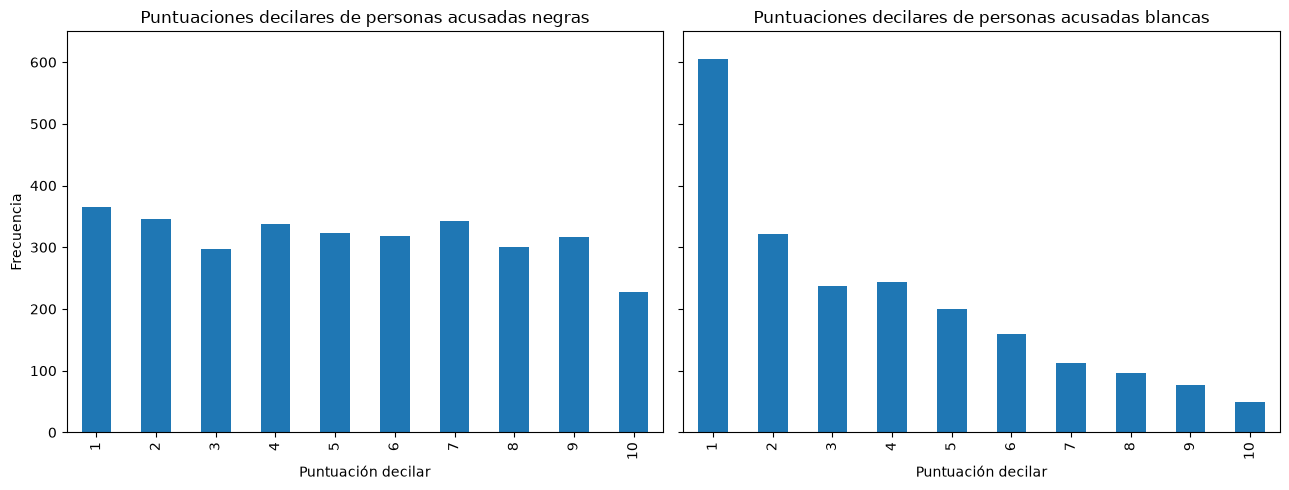

In [14]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for eje, raza, titulo in [
    (ejes[0], "African-American", "Puntuaciones decilares de personas acusadas negras"),
    (ejes[1], "Caucasian", "Puntuaciones decilares de personas acusadas blancas"),
]:
    (
        datos_compas.loc[datos_compas["race"].eq(raza), "decile_score"]
        .value_counts()
        .sort_index()
        .plot.bar(ax=eje)
    )
    eje.set_title(titulo)
    eje.set_xlabel("Puntuación decilar")
    eje.set_ylabel("Frecuencia")
    eje.set_ylim(0, 650)

figura.tight_layout()
plt.show()

In [15]:
pd.crosstab(datos_compas["decile_score"], datos_compas["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Sesgo racial en COMPAS

Después de eliminar las filas no válidas, se evalúa si existen diferencias significativas entre las puntuaciones COMPAS de grupos raciales distintos. Para ello se ajusta una regresión logística que compara puntuaciones bajas con puntuaciones medias o altas.

In [16]:
datos_logisticos = datos_compas.copy()
datos_logisticos["riesgo_alto"] = datos_logisticos["score_text"].ne("Low").astype(int)

formula_logistica = (
    "riesgo_alto ~ "
    "C(sex, Treatment(reference='Male')) + "
    "C(age_cat, Treatment(reference='25 - 45')) + "
    "C(race, Treatment(reference='Caucasian')) + "
    "priors_count + "
    "C(c_charge_degree, Treatment(reference='F')) + "
    "two_year_recid"
)

modelo_logistico = smf.logit(formula_logistica, data=datos_logisticos).fit(disp=False)
logist = mostrar_resultados_logisticos(modelo_logistico)
logist

,Coeficiente,Error estándar,Estadístico z,Valor p,IC 95% inferior,IC 95% superior,Razón de momios
Intercept,-1.525538,0.078515,-19.430004,4.303325e-84,-1.679424,-1.371653,0.217504
"C(sex, Treatment(reference='Male'))[T.Female]",0.221267,0.079510,2.782870,5.388046e-03,0.065429,0.377104,1.247656
"C(age_cat, Treatment(reference='25 - 45'))[T.Greater than 45]",-1.355633,0.099081,-13.682110,1.298682e-42,-1.549828,-1.161439,0.257784
"C(age_cat, Treatment(reference='25 - 45'))[T.Less than 25]",1.308390,0.075929,17.231823,1.532449e-66,1.159573,1.457208,3.700213
"C(race, Treatment(reference='Caucasian'))[T.African-American]",0.477207,0.069349,6.881220,5.934215e-12,0.341285,0.613129,1.611567
"C(race, Treatment(reference='Caucasian'))[T.Asian]",-0.254415,0.478211,-0.532013,5.947169e-01,-1.191692,0.682862,0.775370
"C(race, Treatment(reference='Caucasian'))[T.Hispanic]",-0.428395,0.128126,-3.343555,8.271232e-04,-0.679516,-0.177273,0.651554
"C(race, Treatment(reference='Caucasian'))[T.Native American]",1.394208,0.766119,1.819833,6.878450e-02,-0.107357,2.895773,4.031779
"C(race, Treatment(reference='Caucasian'))[T.Other]",-0.826347,0.162080,-5.098384,3.425657e-07,-1.144018,-0.508676,0.437645
"C(c_charge_degree, Treatment(reference='F'))[T.M]",-0.311241,0.066548,-4.676970,2.911452e-06,-0.441672,-0.180810,0.732537


Las personas acusadas negras tienen una probabilidad 45% mayor que las blancas de recibir una puntuación más alta, al controlar por gravedad del cargo, detenciones previas y reincidencia futura.

In [17]:
probabilidad_control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
np.exp(0.47721) / (1 - probabilidad_control + probabilidad_control * np.exp(0.47721))

np.float64(1.4528408658138932)

Las mujeres tienen una probabilidad 19.4% mayor que los hombres de recibir una puntuación más alta.

In [18]:
np.exp(0.22127) / (1 - probabilidad_control + probabilidad_control * np.exp(0.22127))

np.float64(1.1947978508506671)

De manera destacada, las personas menores de 25 años tienen una probabilidad aproximadamente 2.5 veces mayor que las de edad media de recibir una puntuación más alta.

In [19]:
np.exp(1.30839) / (1 - probabilidad_control + probabilidad_control * np.exp(1.30839))

np.float64(2.4961202077189455)

### Riesgo de reincidencia violenta

COMPAS también ofrece una puntuación diseñada para medir el riesgo de reincidencia violenta. Al igual que antes, se utiliza una regresión logística para evaluar sesgo racial.

In [20]:
datos_crudos_violentos = pd.read_csv(
    RUTA_DATOS / "compas-scores-two-years-violent.csv"
)
len(datos_crudos_violentos)

4743

In [21]:
columnas_violentas = [
    "age",
    "c_charge_degree",
    "race",
    "age_cat",
    "v_score_text",
    "sex",
    "priors_count",
    "days_b_screening_arrest",
    "v_decile_score",
    "is_recid",
    "two_year_recid",
]

datos_violentos = datos_crudos_violentos.loc[:, columnas_violentas].copy()
datos_violentos = datos_violentos.loc[
    datos_violentos["days_b_screening_arrest"].between(-30, 30)
    & datos_violentos["is_recid"].ne(-1)
    & datos_violentos["c_charge_degree"].ne("O")
    & datos_violentos["v_score_text"].ne("N/A")
].copy()

len(datos_violentos)

4020

In [22]:
mostrar_frecuencias(datos_violentos["age_cat"])

age_cat
25 - 45            2300
Greater than 45     954
Less than 25        766
Name: count, dtype: int64

In [23]:
mostrar_frecuencias(datos_violentos["race"])

race
African-American    1918
Caucasian           1459
Hispanic             355
Other                255
Asian                 26
Native American        7
Name: count, dtype: int64

In [24]:
mostrar_frecuencias(datos_violentos["v_score_text"])

v_score_text
Low       2913
Medium     828
High       279
Name: count, dtype: int64

In [25]:
porcentaje(datos_violentos["two_year_recid"].eq(1).sum(), len(datos_violentos))

np.float64(16.218905472636816)

In [26]:
int(datos_violentos["two_year_recid"].eq(1).sum())

652

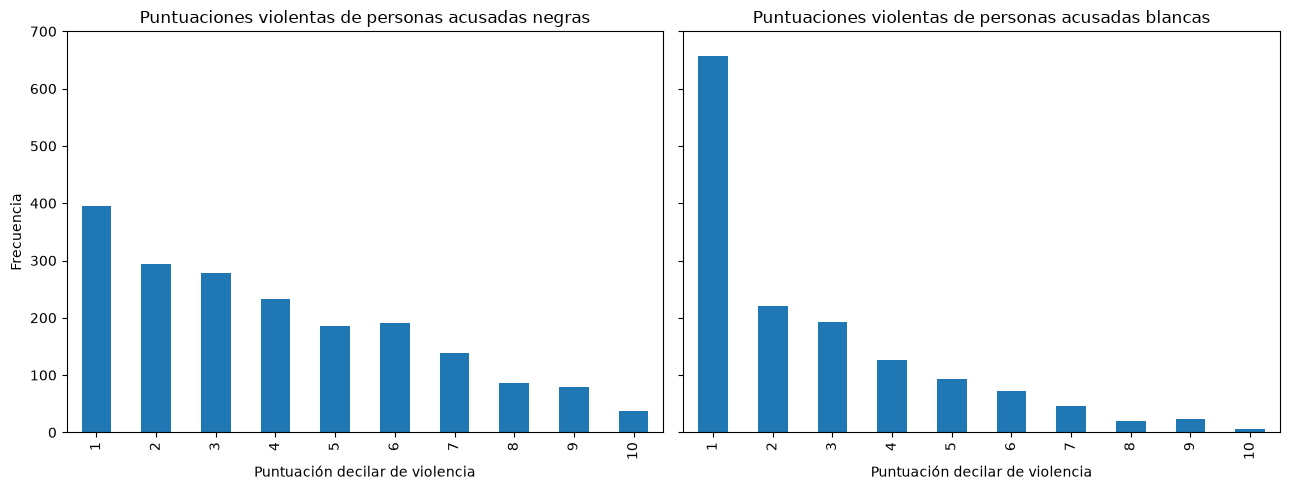

In [27]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for eje, raza, titulo in [
    (ejes[0], "African-American", "Puntuaciones violentas de personas acusadas negras"),
    (ejes[1], "Caucasian", "Puntuaciones violentas de personas acusadas blancas"),
]:
    (
        datos_violentos.loc[datos_violentos["race"].eq(raza), "v_decile_score"]
        .value_counts()
        .sort_index()
        .plot.bar(ax=eje)
    )
    eje.set_title(titulo)
    eje.set_xlabel("Puntuación decilar de violencia")
    eje.set_ylabel("Frecuencia")
    eje.set_ylim(0, 700)

figura.tight_layout()
plt.show()

In [28]:
datos_logisticos_violentos = datos_violentos.copy()
datos_logisticos_violentos["riesgo_alto"] = (
    datos_logisticos_violentos["v_score_text"].ne("Low").astype(int)
)

formula_logistica_violenta = (
    "riesgo_alto ~ "
    "C(sex, Treatment(reference='Male')) + "
    "C(age_cat, Treatment(reference='25 - 45')) + "
    "C(race, Treatment(reference='Caucasian')) + "
    "priors_count + "
    "C(c_charge_degree, Treatment(reference='F')) + "
    "two_year_recid"
)

modelo_logistico_violento = smf.logit(
    formula_logistica_violenta,
    data=datos_logisticos_violentos,
).fit(disp=False)

mostrar_resultados_logisticos(modelo_logistico_violento)

,Coeficiente,Error estándar,Estadístico z,Valor p,IC 95% inferior,IC 95% superior,Razón de momios
Intercept,-2.242739,0.113260,-19.801686,2.878954e-87,-2.464724,-2.020753,0.106167
"C(sex, Treatment(reference='Male'))[T.Female]",-0.728904,0.126655,-5.755029,8.662710e-09,-0.977143,-0.480664,0.482438
"C(age_cat, Treatment(reference='25 - 45'))[T.Greater than 45]",-1.742076,0.184148,-9.460205,3.073410e-21,-2.102999,-1.381153,0.175156
"C(age_cat, Treatment(reference='25 - 45'))[T.Less than 25]",3.145909,0.115410,27.258552,1.315932e-163,2.919710,3.372108,23.240793
"C(race, Treatment(reference='Caucasian'))[T.African-American]",0.658935,0.108150,6.092788,1.109611e-09,0.446965,0.870904,1.932732
"C(race, Treatment(reference='Caucasian'))[T.Asian]",-0.985206,0.705370,-1.396721,1.624974e-01,-2.367707,0.397295,0.373362
"C(race, Treatment(reference='Caucasian'))[T.Hispanic]",-0.064159,0.191328,-0.335338,7.373704e-01,-0.439155,0.310836,0.937855
"C(race, Treatment(reference='Caucasian'))[T.Native American]",0.447930,1.035461,0.432590,6.653128e-01,-1.581536,2.477396,1.565069
"C(race, Treatment(reference='Caucasian'))[T.Other]",-0.205432,0.224641,-0.914493,3.604577e-01,-0.645720,0.234855,0.814295
"C(c_charge_degree, Treatment(reference='F'))[T.M]",-0.163667,0.098065,-1.668963,9.512473e-02,-0.355872,0.028537,0.849024


La puntuación de violencia sobrepredice la reincidencia de personas acusadas negras en 77.3% respecto a las personas acusadas blancas.

In [29]:
probabilidad_control = np.exp(-2.24274) / (1 + np.exp(-2.24274))
np.exp(0.65893) / (1 - probabilidad_control + probabilidad_control * np.exp(0.65893))

np.float64(1.7739209589164604)

Las personas acusadas menores de 25 años tienen una probabilidad 7.4 veces mayor que las de edad media de recibir una puntuación más alta.

In [30]:
np.exp(3.14591) / (1 - probabilidad_control + probabilidad_control * np.exp(3.14591))

np.float64(7.414239863565466)

## Exactitud predictiva de COMPAS

Para evaluar si las puntuaciones COMPAS clasifican adecuadamente a las personas en riesgo bajo, medio o alto, se utiliza un modelo de riesgos proporcionales de Cox. Northpointe, la empresa que creó COMPAS y lo comercializa para fuerzas de seguridad, también aplicó un modelo de Cox en su [estudio de validación](http://cjb.sagepub.com/content/36/1/21.abstract).

Se usa un modelo de conteo y se excluyen periodos en los que las personas están encarceladas. Debido a errores en los datos de cárcel, se eliminan las filas cuya fecha final no es posterior a la inicial. Puesto que son 32 filas de un total de 13,334, estos errores no deberían alterar los resultados de forma relevante.

In [31]:
datos_supervivencia = pd.read_csv(RUTA_DATOS / "cox-parsed.csv")
datos_supervivencia = datos_supervivencia.loc[
    datos_supervivencia["score_text"].notna()
    & datos_supervivencia["end"].gt(datos_supervivencia["start"])
].copy()

datos_supervivencia = preparar_datos_cox(datos_supervivencia)
personas_supervivencia = datos_por_persona(datos_supervivencia)

len(personas_supervivencia)

10314

In [32]:
mostrar_frecuencias(personas_supervivencia["score_text"])

score_text
Low       5751
Medium    2611
High      1952
Name: count, dtype: int64

In [33]:
mostrar_frecuencias(personas_supervivencia["race"])

race
African-American    5147
Caucasian           3569
Hispanic             944
Other                571
Asian                 51
Native American       32
Name: count, dtype: int64

In [34]:
covariables_puntaje = ["puntaje_Medium", "puntaje_High"]
modelo_cox_puntaje = ajustar_modelo_cox(
    datos_supervivencia,
    covariables_puntaje,
)

,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
puntaje_Medium,0.796268,2.21725,0.040772,0.716357,0.876179,2.046962,2.401704,0.0,19.529979,6.106418e-85,279.753562
puntaje_High,1.249693,3.48927,0.041457,1.168437,1.330948,3.216962,3.784629,0.0,30.143960,1.287118e-199,660.699547


Las personas clasificadas en la categoría alta tienen aproximadamente 3.5 veces más probabilidad de reincidir. El índice de concordancia del sistema COMPAS es 63.6%, inferior al 68% reportado por Northpointe.

In [35]:
modelo_cox_decilar = ajustar_modelo_cox(
    datos_supervivencia,
    ["decile_score"],
)

,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
decile_score,0.194931,1.215228,0.005801,0.183563,0.2063,1.20149,1.229122,0.0,33.60591,1.375113e-247,820.05669


Las puntuaciones decilares de COMPAS alcanzan una concordancia ligeramente mayor, cercana a 66%.

Para comprobar si el comportamiento del algoritmo varía entre grupos raciales, se incorporan términos de interacción entre raza y puntuación en el modelo de Cox.

In [36]:
def limpiar_covariables_cox(datos, covariables):
    X = datos[covariables].copy()

    # 1. Quitar columnas constantes
    constantes = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]

    # 2. Quitar columnas duplicadas
    duplicadas = X.T.duplicated()
    columnas_duplicadas = list(X.columns[duplicadas])

    covariables_limpias = [
        c for c in covariables
        if c not in constantes and c not in columnas_duplicadas
    ]

    return covariables_limpias

covariables_raza = [
    columna
    for columna in datos_supervivencia.columns
    if columna.startswith("raza_")
]
covariables_interaccion = [
    columna
    for columna in datos_supervivencia.columns
    if "_x_puntaje_" in columna
]

covariables_totales = (
    covariables_raza
    + covariables_puntaje
    + covariables_interaccion
)

datos_supervivencia = datos_supervivencia.loc[:, ~datos_supervivencia.columns.duplicated()].copy()

covariables_limpias = limpiar_covariables_cox(
    datos_supervivencia,
    list(dict.fromkeys(covariables_totales)),
)

modelo_cox_interaccion = ajustar_modelo_cox(
    datos_supervivencia,
    covariables_limpias
)

,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
raza_African-American,0.278795,1.321536,0.060796,0.159636,0.397953,1.173084,1.488775,0.0,4.585708,4.524507e-06,17.753808
raza_Asian,-0.776935,0.459813,0.502002,-1.760841,0.206971,0.171900,1.229947,0.0,-1.547673,1.217010e-01,3.038587
raza_Hispanic,-0.063516,0.938459,0.096732,-0.253108,0.126075,0.776384,1.134367,0.0,-0.656624,5.114229e-01,0.967411
raza_Native American,-1.254681,0.285167,1.001004,-3.216612,0.707251,0.040091,2.028407,0.0,-1.253422,2.100520e-01,2.251182
raza_Other,0.014193,1.014294,0.110491,-0.202366,0.230751,0.816796,1.259546,0.0,0.128452,8.977916e-01,0.155547
raza_African-American_x_puntaje_Medium,-0.172607,0.841469,0.090973,-0.350910,0.005697,0.704047,1.005714,0.0,-1.897337,5.778350e-02,4.113199
raza_African-American_x_puntaje_High,-0.189757,0.827160,0.099851,-0.385461,0.005947,0.680137,1.005965,0.0,-1.900402,5.738040e-02,4.123298
raza_Asian_x_puntaje_Medium,0.986193,2.681008,0.710715,-0.406784,2.379169,0.665788,10.795932,0.0,1.387606,1.652571e-01,2.597216
raza_Asian_x_puntaje_High,1.315559,3.726836,0.768351,-0.190381,2.821500,0.826644,16.802031,0.0,1.712186,8.686248e-02,3.525123


El término de interacción muestra una disparidad similar a la observada en la regresión logística.

Las personas acusadas blancas con riesgo alto tienen 3.61 veces más probabilidad de reincidir que las blancas con riesgo bajo, mientras que para las personas acusadas negras el factor es 2.99.

In [37]:
print(f"Riesgo relativo alto para personas negras: {np.exp(-0.18976 + 1.28350):.2f}")
print(f"Riesgo relativo alto para personas blancas: {np.exp(1.28350):.2f}")
print(f"Riesgo relativo medio para personas negras: {np.exp(0.84286 - 0.17261):.2f}")
print(f"Riesgo relativo medio para personas blancas: {np.exp(0.84286):.2f}")

Riesgo relativo alto para personas negras: 2.99
Riesgo relativo alto para personas blancas: 3.61
Riesgo relativo medio para personas negras: 1.95
Riesgo relativo medio para personas blancas: 2.32


C:\Users\PC\AppData\Local\Temp\ipykernel_21792\3026898033.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, subconjunto in datos.dropna(subset=[columna_grupo]).groupby(columna_grupo):


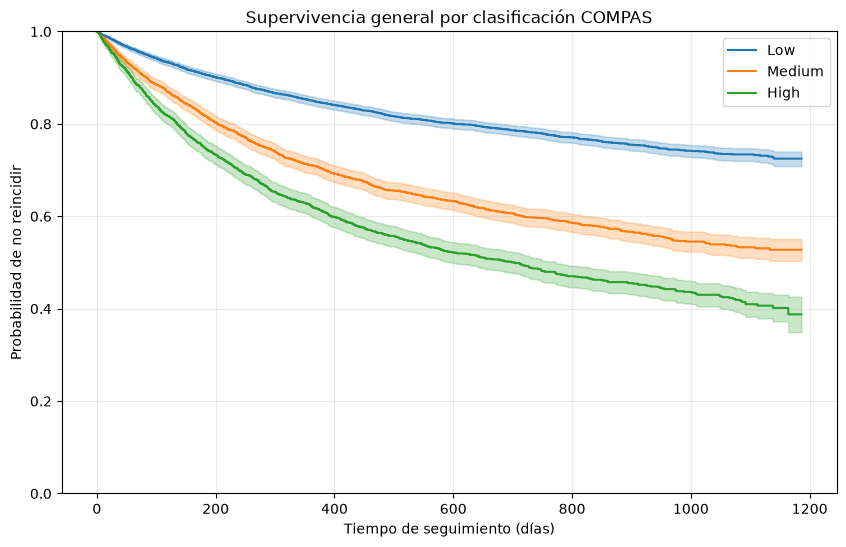

In [38]:
ajustes_puntaje = ajustar_km_por_grupo(
    personas_supervivencia,
    "score_text",
)
graficar_ajustes_km(
    ajustes_puntaje,
    "Supervivencia general por clasificación COMPAS",
)
plt.show()

Según las curvas Kaplan-Meier específicas por raza, las personas acusadas negras reinciden a tasas más altas.

C:\Users\PC\AppData\Local\Temp\ipykernel_21792\3026898033.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, subconjunto in datos.dropna(subset=[columna_grupo]).groupby(columna_grupo):
C:\Users\PC\AppData\Local\Temp\ipykernel_21792\3026898033.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, subconjunto in datos.dropna(subset=[columna_grupo]).groupby(columna_grupo):


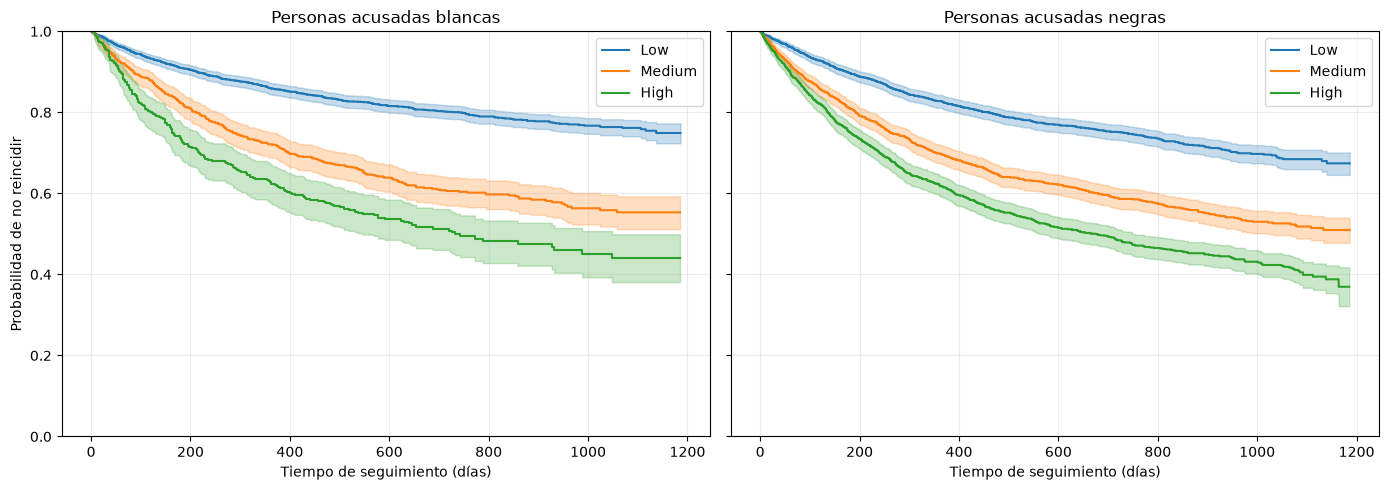

In [39]:
personas_blancas = personas_supervivencia.loc[
    personas_supervivencia["race"].eq("Caucasian")
]
personas_negras = personas_supervivencia.loc[
    personas_supervivencia["race"].eq("African-American")
]

ajustes_blancos = ajustar_km_por_grupo(personas_blancas, "score_text")
ajustes_negros = ajustar_km_por_grupo(personas_negras, "score_text")

figura, ejes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
graficar_ajustes_km(ajustes_blancos, "Personas acusadas blancas", ejes[0])
graficar_ajustes_km(ajustes_negros, "Personas acusadas negras", ejes[1])
figura.tight_layout()
plt.show()

In [40]:
supervivencia_en_tiempo(ajustes_puntaje, tiempo=730)

,Grupo,Supervivencia a 730 días
0,Low,0.781964
1,Medium,0.597728
2,High,0.488689


In [41]:
supervivencia_en_tiempo(ajustes_negros, tiempo=730)

,Grupo,Supervivencia a 730 días
0,Low,0.750393
1,Medium,0.586240
2,High,0.479891


In [42]:
supervivencia_en_tiempo(ajustes_blancos, tiempo=730)

,Grupo,Supervivencia a 730 días
0,Low,0.800578
1,Medium,0.605815
2,High,0.504033


Los modelos específicos por raza tienen índices de concordancia similares.

In [43]:
modelo_cox_blancos = ajustar_modelo_cox(
    datos_supervivencia.loc[datos_supervivencia["race"].eq("Caucasian")],
    covariables_puntaje,
)

,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
puntaje_Medium,0.839650,2.315557,0.07144,0.699630,0.979670,2.013007,2.663578,0.0,11.753186,6.800534e-32,103.536051
puntaje_High,1.276276,3.583272,0.08365,1.112325,1.440228,3.041421,4.221658,0.0,15.257297,1.472220e-52,172.182268


In [44]:
modelo_cox_negros = ajustar_modelo_cox(
    datos_supervivencia.loc[datos_supervivencia["race"].eq("African-American")],
    covariables_puntaje,
)

,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
puntaje_Medium,0.670253,1.954732,0.056363,0.559784,0.780723,1.750295,2.183049,0.0,11.891750,1.306407e-32,105.916095
puntaje_High,1.095137,2.989591,0.054750,0.987828,1.202445,2.685395,3.328246,0.0,20.002363,5.252373e-89,293.258631


La puntuación de reincidencia violenta de COMPAS tiene una concordancia global ligeramente mayor, de aproximadamente 65.1%.

In [45]:
datos_supervivencia_violenta = pd.read_csv(
    RUTA_DATOS / "cox-violent-parsed.csv"
)
datos_supervivencia_violenta = datos_supervivencia_violenta.loc[
    datos_supervivencia_violenta["score_text"].ne("N/A")
    & datos_supervivencia_violenta["end"].gt(
        datos_supervivencia_violenta["start"]
    )
].copy()

datos_supervivencia_violenta = preparar_datos_cox(datos_supervivencia_violenta)
personas_supervivencia_violenta = datos_por_persona(datos_supervivencia_violenta)

covariables_puntaje_violento = ["puntaje_Medium", "puntaje_High"]
modelo_cox_violento = ajustar_modelo_cox(
    datos_supervivencia_violenta,
    covariables_puntaje_violento,
)

print(len(personas_supervivencia_violenta))

,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
puntaje_Medium,0.903391,2.467958,0.111492,0.684870,1.121911,1.983515,3.070718,0.0,8.102732,5.373849e-16,50.724894
puntaje_High,1.423212,4.150432,0.108852,1.209867,1.636558,3.353037,5.137458,0.0,13.074754,4.590461e-39,127.356557


10932


En este caso, no hay un coeficiente significativo para las personas acusadas negras con puntuaciones altas.

In [46]:
covariables_raza_violenta = [
    columna
    for columna in datos_supervivencia_violenta.columns
    if columna.startswith("raza_")
]
covariables_interaccion_violenta = [
    columna
    for columna in datos_supervivencia_violenta.columns
    if "_x_puntaje_" in columna
]

covariables_totales_violentas = list(
    dict.fromkeys(
        covariables_raza_violenta
        + covariables_puntaje_violento
        + covariables_interaccion_violenta
    )
)

covariables_limpias_violentas = limpiar_covariables_cox(
    datos_supervivencia_violenta,
    covariables_totales_violentas,
)

datos_modelo_violento = datos_supervivencia_violenta[
    ["id", "start", "end", "event", *covariables_limpias_violentas]
].dropna().copy()

modelo_cox_interaccion_violento = CoxTimeVaryingFitter(penalizer=0.01)
modelo_cox_interaccion_violento.fit(
    datos_modelo_violento,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event",
    show_progress=False,
)

resumen = modelo_cox_interaccion_violento.summary.rename(
    columns={
        "coef": "Coeficiente",
        "exp(coef)": "Razón de riesgos",
        "se(coef)": "Error estándar",
        "coef lower 95%": "IC 95% inferior (coef.)",
        "coef upper 95%": "IC 95% superior (coef.)",
        "exp(coef) lower 95%": "IC 95% inferior (RR)",
        "exp(coef) upper 95%": "IC 95% superior (RR)",
        "cmp to": "Comparación",
        "z": "Estadístico z",
        "p": "Valor p",
        "-log2(p)": "-log2(valor p)",
    }
)
display(resumen)

if hasattr(modelo_cox_interaccion_violento, "concordance_index_"):
    print(f"Índice de concordancia: {modelo_cox_interaccion_violento.concordance_index_:.4f}")

d:\Escuela\Maestría\Proyecto Tecnologico\.venv\Lib\site-packages\lifelines\utils\__init__.py:1120: ConvergenceWarning: Column raza_Asian_x_puntaje_High have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event'].astype(bool)
>>> print(df.loc[events, 'raza_Asian_x_puntaje_High'].var())
>>> print(df.loc[~events, 'raza_Asian_x_puntaje_High'].var())

A very low variance means that the column raza_Asian_x_puntaje_High completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
raza_African-American,0.042830,1.043760,0.107026,-0.166938,0.252597,0.846252,1.287364,0.0,0.400180,6.890239e-01,0.537374
raza_Asian,-0.942030,0.389836,0.967276,-2.837856,0.953797,0.058551,2.595546,0.0,-0.973899,3.301066e-01,1.598996
raza_Hispanic,-0.198454,0.819997,0.195833,-0.582280,0.185371,0.558623,1.203665,0.0,-1.013387,3.108754e-01,1.685592
raza_Native American,-0.396361,0.672763,0.983217,-2.323432,1.530709,0.097937,4.621453,0.0,-0.403127,6.868548e-01,0.541923
raza_Other,-0.108436,0.897237,0.234863,-0.568759,0.351888,0.566228,1.421749,0.0,-0.461697,6.442987e-01,0.634198
raza_African-American_x_puntaje_Medium,0.280026,1.323165,0.154024,-0.021855,0.581908,0.978382,1.789449,0.0,1.818071,6.905330e-02,3.856146
raza_African-American_x_puntaje_High,0.353937,1.424665,0.156283,0.047627,0.660247,1.048780,1.935270,0.0,2.264714,2.353025e-02,5.409340
raza_Asian_x_puntaje_Medium,1.469859,4.348623,1.354281,-1.184482,4.124201,0.305905,61.818367,0.0,1.085343,2.777697e-01,1.848039
raza_Asian_x_puntaje_High,-0.436134,0.646531,3.168691,-6.646654,5.774386,0.001298,321.946765,0.0,-0.137639,8.905261e-01,0.167270


In [47]:
modelo_cox_violento_negros = ajustar_modelo_cox(
    datos_supervivencia_violenta.loc[
        datos_supervivencia_violenta["race"].eq("African-American")
    ],
    covariables_puntaje_violento,
)

,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
puntaje_Medium,0.900737,2.461417,0.157535,0.591974,1.209500,1.807554,3.351808,0.0,5.717699,1.079765e-08,26.464708
puntaje_High,1.314386,3.722463,0.150301,1.019801,1.608971,2.772642,4.997664,0.0,8.745009,2.229980e-18,58.637675


In [48]:
modelo_cox_violento_blancos = ajustar_modelo_cox(
    datos_supervivencia_violenta.loc[
        datos_supervivencia_violenta["race"].eq("Caucasian")
    ],
    covariables_puntaje_violento,
)

,Coeficiente,Razón de riesgos,Error estándar,IC 95% inferior (coef.),IC 95% superior (coef.),IC 95% inferior (RR),IC 95% superior (RR),Comparación,Estadístico z,Valor p,-log2(valor p)
covariate,,,,,,,,,,,
puntaje_Medium,0.755038,2.127693,0.19627,0.370356,1.139721,1.448251,3.125895,0.0,3.846938,1.196033e-04,13.029455
puntaje_High,1.340007,3.819069,0.21922,0.910344,1.769670,2.485176,5.868914,0.0,6.112615,9.801148e-10,29.926330


C:\Users\PC\AppData\Local\Temp\ipykernel_21792\3026898033.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, subconjunto in datos.dropna(subset=[columna_grupo]).groupby(columna_grupo):
C:\Users\PC\AppData\Local\Temp\ipykernel_21792\3026898033.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, subconjunto in datos.dropna(subset=[columna_grupo]).groupby(columna_grupo):


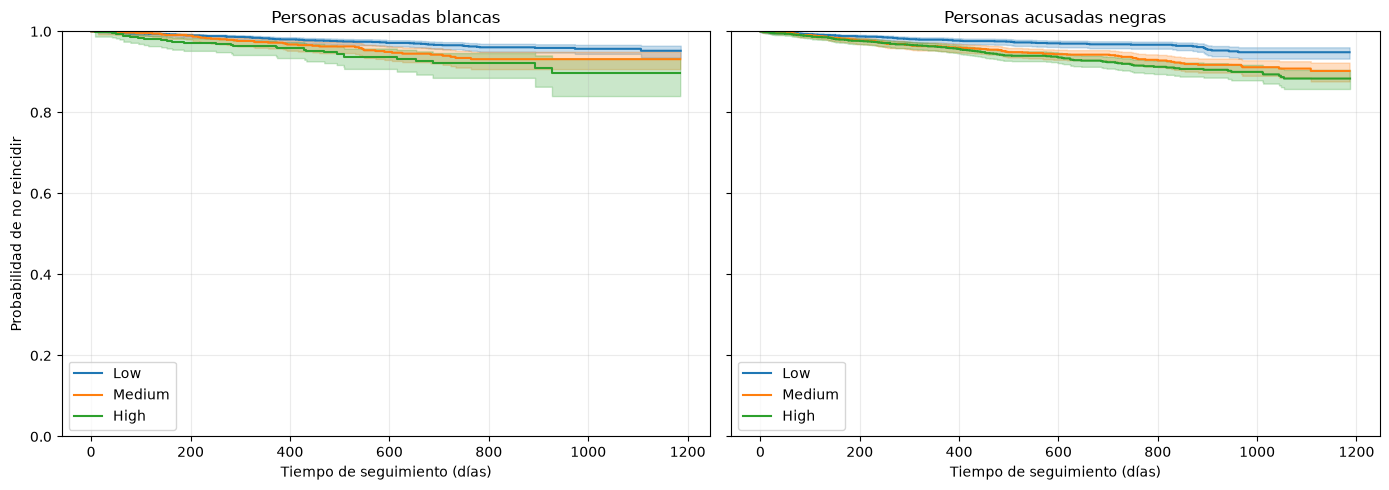

In [49]:
personas_blancas_violentas = personas_supervivencia_violenta.loc[
    personas_supervivencia_violenta["race"].eq("Caucasian")
]
personas_negras_violentas = personas_supervivencia_violenta.loc[
    personas_supervivencia_violenta["race"].eq("African-American")
]

ajustes_blancos_violentos = ajustar_km_por_grupo(
    personas_blancas_violentas,
    "score_text",
)
ajustes_negros_violentos = ajustar_km_por_grupo(
    personas_negras_violentas,
    "score_text",
)

figura, ejes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
graficar_ajustes_km(
    ajustes_blancos_violentos,
    "Personas acusadas blancas",
    ejes[0],
)
graficar_ajustes_km(
    ajustes_negros_violentos,
    "Personas acusadas negras",
    ejes[1],
)
figura.tight_layout()
plt.show()

## Dirección del sesgo racial

El análisis anterior muestra que el algoritmo COMPAS sobrepredice la reincidencia futura de las personas acusadas negras. Ahora se evalúa la dirección del sesgo comparando los errores de clasificación entre grupos raciales.

In [50]:
personas = cargar_personas(RUTA_DATOS / "cox-parsed.csv")
poblacion = seleccionar_poblacion_dos_anios(
    personas,
    columna_puntaje="score_text",
    columna_evento="is_recid",
)

reincidentes = poblacion.loc[poblacion["reincidio_evento"]].copy()
no_reincidentes = poblacion.loc[~poblacion["reincidio_evento"]].copy()

In [51]:
print("Todas las personas acusadas")
tabla_general, metricas_generales = mostrar_tabla_confusion(
    reincidentes,
    no_reincidentes,
    columna_puntaje="score_text",
)

Todas las personas acusadas


,Riesgo bajo,Riesgo alto
No reincidió,2681,1282
Reincidió,1216,2035


,Valor
Tasa de falsos positivos (%),32.349230
Tasa de falsos negativos (%),37.403876
Especificidad,0.676508
Sensibilidad,0.625961
Prevalencia,0.450652
VPP,0.613506
VPN,0.687965
RV+,1.935011
RV-,0.552897


In [52]:
print(f"Población total: {len(poblacion)}")

Población total: 7214


In [53]:
print(
    "Tiempo promedio de seguimiento "
    f"{poblacion['tiempo_seguimiento'].mean():.2f} "
    f"(desviación estándar {poblacion['tiempo_seguimiento'].std():.2f})"
)
print(
    "Tiempo mediano de seguimiento "
    f"{poblacion['tiempo_seguimiento'].median():.0f}"
)

Tiempo promedio de seguimiento 622.87 (desviación estándar 392.19)
Tiempo mediano de seguimiento 766


La tasa global de falsos positivos es 32.35%.

In [54]:
print("Personas acusadas negras")
es_negra = reincidentes["race"].eq("African-American")
es_negra_no_reincidente = no_reincidentes["race"].eq("African-American")
tabla_negras, metricas_negras = mostrar_tabla_confusion(
    reincidentes.loc[es_negra],
    no_reincidentes.loc[es_negra_no_reincidente],
    columna_puntaje="score_text",
)

Personas acusadas negras


,Riesgo bajo,Riesgo alto
No reincidió,990,805
Reincidió,532,1369


,Valor
Tasa de falsos positivos (%),44.846797
Tasa de falsos negativos (%),27.985271
Especificidad,0.551532
Sensibilidad,0.720147
Prevalencia,0.514340
VPP,0.629715
VPN,0.650460
RV+,1.605794
RV-,0.507410


La tasa es mayor para las personas acusadas negras: 44.85%.

In [55]:
print("Personas acusadas blancas")
es_blanca = reincidentes["race"].eq("Caucasian")
es_blanca_no_reincidente = no_reincidentes["race"].eq("Caucasian")
tabla_blancas, metricas_blancas = mostrar_tabla_confusion(
    reincidentes.loc[es_blanca],
    no_reincidentes.loc[es_blanca_no_reincidente],
    columna_puntaje="score_text",
)

Personas acusadas blancas


,Riesgo bajo,Riesgo alto
No reincidió,1139,349
Reincidió,461,505


,Valor
Tasa de falsos positivos (%),23.454301
Tasa de falsos negativos (%),47.722567
Especificidad,0.765457
Sensibilidad,0.522774
Prevalencia,0.393643
VPP,0.591335
VPN,0.711875
RV+,2.228906
RV-,0.623452


La tasa es menor para las personas acusadas blancas: 23.45%.

In [56]:
44.85 / 23.45

1.9125799573560769

Esto significa que, bajo COMPAS, las personas acusadas negras tienen 91% más probabilidad de recibir una puntuación alta y no reincidir en los siguientes dos años que las personas acusadas blancas.

Las puntuaciones COMPAS clasifican erróneamente a las personas blancas que reinciden como de bajo riesgo 70.4% más veces que a las personas negras que reinciden.

In [57]:
47.72 / 27.99

1.7048946052161487

In [58]:
mostrar_tabla_confusion(
    reincidentes.loc[es_blanca],
    no_reincidentes.loc[es_blanca_no_reincidente],
    columna_puntaje="score_text",
    solo_alto=True,
)

,Riesgo bajo,Riesgo alto
No reincidió,1407,81
Reincidió,771,195


,Valor
Tasa de falsos positivos (%),5.443548
Tasa de falsos negativos (%),79.813665
Especificidad,0.945565
Sensibilidad,0.201863
Prevalencia,0.393643
VPP,0.706522
VPN,0.646006
RV+,3.708305
RV-,0.844085


(              Riesgo bajo  Riesgo alto
 No reincidió         1407           81
 Reincidió             771          195,
 Tasa de falsos positivos (%)     5.443548
 Tasa de falsos negativos (%)    79.813665
 Especificidad                    0.945565
 Sensibilidad                     0.201863
 Prevalencia                      0.393643
 VPP                              0.706522
 VPN                              0.646006
 RV+                              3.708305
 RV-                              0.844085
 dtype: float64)

In [59]:
mostrar_tabla_confusion(
    reincidentes.loc[es_negra],
    no_reincidentes.loc[es_negra_no_reincidente],
    columna_puntaje="score_text",
    solo_alto=True,
)

,Riesgo bajo,Riesgo alto
No reincidió,1511,284
Reincidió,1160,741


,Valor
Tasa de falsos positivos (%),15.821727
Tasa de falsos negativos (%),61.020516
Especificidad,0.841783
Sensibilidad,0.389795
Prevalencia,0.514340
VPP,0.722927
VPN,0.565706
RV+,2.463668
RV-,0.724896


(              Riesgo bajo  Riesgo alto
 No reincidió         1511          284
 Reincidió            1160          741,
 Tasa de falsos positivos (%)    15.821727
 Tasa de falsos negativos (%)    61.020516
 Especificidad                    0.841783
 Sensibilidad                     0.389795
 Prevalencia                      0.514340
 VPP                              0.722927
 VPN                              0.565706
 RV+                              2.463668
 RV-                              0.724896
 dtype: float64)

## Riesgo de reincidencia violenta

COMPAS también ofrece una puntuación para estimar el riesgo de reincidencia violenta, con una exactitud global similar a la de reincidencia general.

In [60]:
personas_violentas = cargar_personas(RUTA_DATOS / "cox-violent-parsed.csv")
poblacion_violenta = seleccionar_poblacion_dos_anios(
    personas_violentas,
    columna_puntaje="v_score_text",
    columna_evento="is_violent_recid",
)

reincidentes_violentos = poblacion_violenta.loc[
    poblacion_violenta["reincidio_evento"]
].copy()
no_reincidentes_violentos = poblacion_violenta.loc[
    ~poblacion_violenta["reincidio_evento"]
].copy()

In [61]:
print("Todas las personas acusadas")
tabla_violenta_general, metricas_violentas_generales = mostrar_tabla_confusion(
    reincidentes_violentos,
    no_reincidentes_violentos,
    columna_puntaje="v_score_text",
)

Todas las personas acusadas


,Riesgo bajo,Riesgo alto
No reincidió,2040,587
Reincidió,313,494


,Valor
Tasa de falsos positivos (%),22.344880
Tasa de falsos negativos (%),38.785626
Especificidad,0.776551
Sensibilidad,0.612144
Prevalencia,0.235003
VPP,0.456984
VPN,0.866978
RV+,2.739526
RV-,0.499460


La diferencia es todavía mayor para las personas acusadas negras.

In [62]:
print("Personas acusadas negras")
tabla_violenta_negras, metricas_violentas_negras = mostrar_tabla_confusion(
    reincidentes_violentos.loc[
        reincidentes_violentos["race"].eq("African-American")
    ],
    no_reincidentes_violentos.loc[
        no_reincidentes_violentos["race"].eq("African-American")
    ],
    columna_puntaje="v_score_text",
)

Personas acusadas negras


,Riesgo bajo,Riesgo alto
No reincidió,813,373
Reincidió,148,356


,Valor
Tasa de falsos positivos (%),31.450253
Tasa de falsos negativos (%),29.365079
Especificidad,0.685497
Sensibilidad,0.706349
Prevalencia,0.298225
VPP,0.488340
VPN,0.845994
RV+,2.245925
RV-,0.428376


In [63]:
print("Personas acusadas blancas")
tabla_violenta_blancas, metricas_violentas_blancas = mostrar_tabla_confusion(
    reincidentes_violentos.loc[
        reincidentes_violentos["race"].eq("Caucasian")
    ],
    no_reincidentes_violentos.loc[
        no_reincidentes_violentos["race"].eq("Caucasian")
    ],
    columna_puntaje="v_score_text",
)

Personas acusadas blancas


,Riesgo bajo,Riesgo alto
No reincidió,837,134
Reincidió,122,90


,Valor
Tasa de falsos positivos (%),13.800206
Tasa de falsos negativos (%),57.547170
Especificidad,0.861998
Sensibilidad,0.424528
Prevalencia,0.179205
VPP,0.401786
VPN,0.872784
RV+,3.076246
RV-,0.667602


Las personas acusadas negras tienen el doble de probabilidad de ser falsos positivos para una puntuación alta de violencia que las personas acusadas blancas.

In [64]:
38.14 / 18.46

2.066088840736728

Las personas acusadas blancas tienen 63% más probabilidad de recibir una puntuación baja y reincidir que las personas acusadas negras.

In [65]:
62.62 / 38.37

1.63200416992442

## Diferencias por sexo en las puntuaciones COMPAS

En términos de tasas de reincidencia subyacentes, se pueden analizar estimaciones Kaplan-Meier específicas por sexo. Existe una diferencia marcada entre mujeres y hombres.

In [66]:
personas_mujeres = personas_supervivencia.loc[
    personas_supervivencia["sex"].eq("Female")
]
personas_hombres = personas_supervivencia.loc[
    personas_supervivencia["sex"].eq("Male")
]

ajustes_mujeres = ajustar_km_por_grupo(personas_mujeres, "score_text")
ajustes_hombres = ajustar_km_por_grupo(personas_hombres, "score_text")

C:\Users\PC\AppData\Local\Temp\ipykernel_21792\3026898033.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, subconjunto in datos.dropna(subset=[columna_grupo]).groupby(columna_grupo):
C:\Users\PC\AppData\Local\Temp\ipykernel_21792\3026898033.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grupo, subconjunto in datos.dropna(subset=[columna_grupo]).groupby(columna_grupo):


In [67]:
supervivencia_en_tiempo(ajustes_hombres, tiempo=730)

,Grupo,Supervivencia a 730 días
0,Low,0.765773
1,Medium,0.577041
2,High,0.475106


In [68]:
supervivencia_en_tiempo(ajustes_mujeres, tiempo=730)

,Grupo,Supervivencia a 730 días
0,Low,0.840696
1,Medium,0.672190
2,High,0.571467


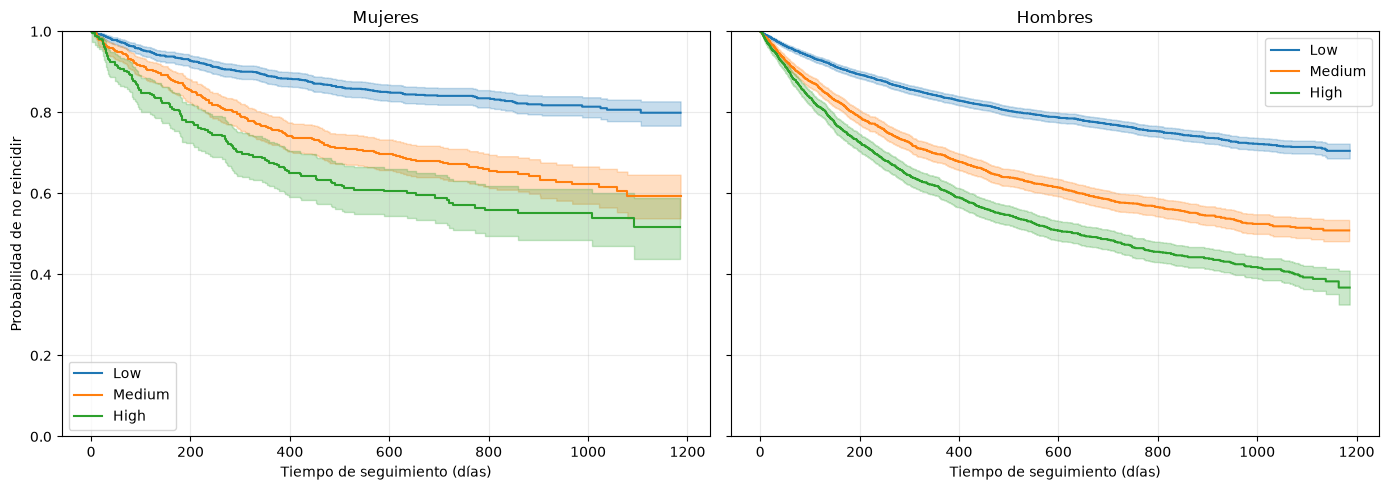

In [69]:
figura, ejes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
graficar_ajustes_km(ajustes_mujeres, "Mujeres", ejes[0])
graficar_ajustes_km(ajustes_hombres, "Hombres", ejes[1])
figura.tight_layout()
plt.show()

Como muestran estas gráficas, la puntuación COMPAS trata a una mujer con riesgo alto de forma similar a un hombre con riesgo medio.